# Skinical — ISIC 2017 Binary Skin Lesion Classification
**Pipeline:** Hair Removal → CLAHE → Feature Extraction (LBP + GLCM + HOG + LAB Histogram) → Augmentation → GBDT

**Label convention (ISIC 2017):**
- `melanoma == 1` → **malignant (1)**
- `melanoma == 0` (nevus OR seborrheic keratosis) → **benign (0)**

> To change: edit the `build_label()` function in Cell 3.

## 0. Install / Import

In [2]:
# ── Installs (Kaggle already has most; mahotas for Haralick) ──────────────────
!pip install mahotas -q

import os, cv2, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm import tqdm

from skimage.feature import local_binary_pattern, hog
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2lab

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.utils import resample

import mahotas
import joblib
warnings.filterwarnings('ignore')
print('All imports OK')


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\alban\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


All imports OK


## 1. Paths — ISIC 2017 Kaggle structure

In [3]:
BASE = Path('/kaggle/input/datasets/johnchfr/isic-2017')

# ── Image folders ─────────────────────────────────────────────────────────────
TRAIN_IMG = BASE / 'ISIC-2017_Training_Data'  / 'ISIC-2017_Training_Data'
VAL_IMG   = BASE / 'ISIC-2017_Validation_Data' / 'ISIC-2017_Validation_Data'
TEST_IMG  = BASE / 'ISIC-2017_Test_v2_Data'    / 'ISIC-2017_Test_v2_Data'

# ── Ground truth CSVs (Part 3 = melanoma / seborrheic_keratosis labels) ───────
TRAIN_GT  = BASE / '/kaggle/input/datasets/johnchfr/isic-2017/ISIC-2017_Training_Part3_GroundTruth.csv'
VAL_GT    = BASE / '/kaggle/input/datasets/johnchfr/isic-2017/ISIC-2017_Validation_Part3_GroundTruth.csv'
TEST_GT   = BASE / '/kaggle/input/datasets/johnchfr/isic-2017/ISIC-2017_Test_v2_Part3_GroundTruth.csv'

# Quick sanity check
for p in [TRAIN_IMG, VAL_IMG, TEST_IMG, TRAIN_GT, VAL_GT, TEST_GT]:
    status = '✓' if p.exists() else '✗ NOT FOUND'
    print(f'{status}  {p}')

✗ NOT FOUND  \kaggle\input\datasets\johnchfr\isic-2017\ISIC-2017_Training_Data\ISIC-2017_Training_Data
✗ NOT FOUND  \kaggle\input\datasets\johnchfr\isic-2017\ISIC-2017_Validation_Data\ISIC-2017_Validation_Data
✗ NOT FOUND  \kaggle\input\datasets\johnchfr\isic-2017\ISIC-2017_Test_v2_Data\ISIC-2017_Test_v2_Data
✗ NOT FOUND  \kaggle\input\datasets\johnchfr\isic-2017\ISIC-2017_Training_Part3_GroundTruth.csv
✗ NOT FOUND  \kaggle\input\datasets\johnchfr\isic-2017\ISIC-2017_Validation_Part3_GroundTruth.csv
✗ NOT FOUND  \kaggle\input\datasets\johnchfr\isic-2017\ISIC-2017_Test_v2_Part3_GroundTruth.csv


## 2. Load Ground Truth CSVs

In [4]:
def load_gt(csv_path):
    df = pd.read_csv(csv_path)
    # Normalise column name  (sometimes 'image_id', sometimes 'image_name')
    df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]
    if 'image_id' not in df.columns:
        df.rename(columns={df.columns[0]: 'image_id'}, inplace=True)
    return df

train_gt = load_gt(TRAIN_GT)
val_gt   = load_gt(VAL_GT)
test_gt  = load_gt(TEST_GT)

print('Train GT shape:', train_gt.shape)
print(train_gt.head(3))
print('\nColumns:', train_gt.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '\\kaggle\\input\\datasets\\johnchfr\\isic-2017\\ISIC-2017_Training_Part3_GroundTruth.csv'

In [ ]:
train_files = os.listdir(TRAIN_IMG)
print(f'Total files: {len(train_files)}')
print(f'Sample: {train_files[:3]}')

Total files: 4001
Sample: ['ISIC_0012706.jpg', 'ISIC_0010192.jpg', 'ISIC_0000466_superpixels.png']


In [ ]:
for root, dirs, files in os.walk(BASE / 'ISIC-2017_Training_Data'):
    print(f'DIR: {root}')
    print(f'  subdirs: {dirs[:3]}')
    print(f'  files: {len(files)}, sample: {files[:2]}')

DIR: /kaggle/input/datasets/johnchfr/isic-2017/ISIC-2017_Training_Data
  subdirs: ['ISIC-2017_Training_Data']
  files: 0, sample: []
DIR: /kaggle/input/datasets/johnchfr/isic-2017/ISIC-2017_Training_Data/ISIC-2017_Training_Data
  subdirs: []
  files: 4001, sample: ['ISIC_0012706.jpg', 'ISIC_0010192.jpg']


## 3. Build Binary Labels

**Default:** `melanoma == 1` → label 1 (malignant), else → label 0 (benign)

To change, edit the `build_label` function below.

=== Train distribution ===
label
0    1626
1     374
Name: count, dtype: int64
Imbalance ratio: 4.3:1


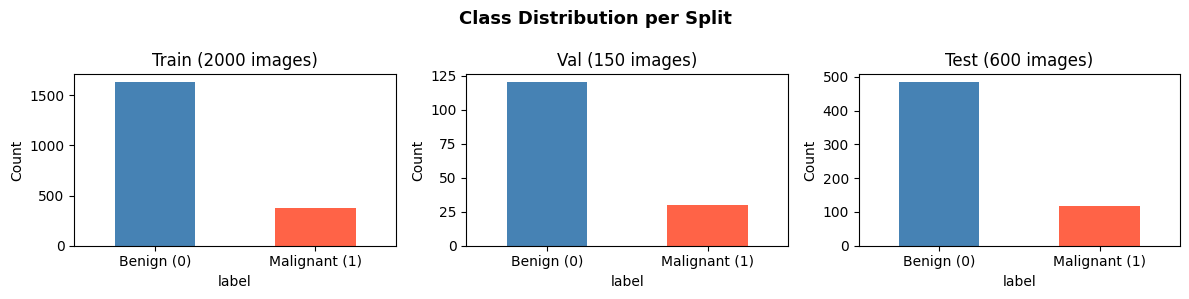

In [ ]:
def build_label(row):
    """
    Default: melanoma=1 → malignant (1), others → benign (0)
    
    Alternative options (uncomment one):
    
    # Option B: melanoma OR seborrheic_keratosis = 1 (both as malignant)
    # return 1 if (row.get('melanoma',0)==1 or row.get('seborrheic_keratosis',0)==1) else 0
    
    # Option C: only nevus (0,0) as benign, rest as malignant
    # return 0 if (row.get('melanoma',0)==0 and row.get('seborrheic_keratosis',0)==0) else 1
    """
    return int(row.get('melanoma', 0) == 1)

for df in [train_gt, val_gt, test_gt]:
    df['label'] = df.apply(build_label, axis=1)

# Class distribution
print('=== Train distribution ===')
print(train_gt['label'].value_counts())
print(f"Imbalance ratio: {train_gt['label'].value_counts()[0] / train_gt['label'].value_counts()[1]:.1f}:1")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, df, title in zip(axes, [train_gt, val_gt, test_gt], ['Train','Val','Test']):
    df['label'].value_counts().plot(kind='bar', ax=ax, color=['steelblue','tomato'])
    ax.set_title(f'{title} ({len(df)} images)')
    ax.set_xticklabels(['Benign (0)','Malignant (1)'], rotation=0)
    ax.set_ylabel('Count')
plt.suptitle('Class Distribution per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── EDA ───────────────────────────────────────────────────────────────────────
print('=' * 55)
print('  EXPLORATORY DATA ANALYSIS — ISIC 2017')
print('=' * 55)

# Statistik dataset
total = len(train_gt) + len(val_gt) + len(test_gt)
print(f'\nTotal images : {total}')
print(f'  Train      : {len(train_gt)}')
print(f'  Validation : {len(val_gt)}')
print(f'  Test       : {len(test_gt)}')

mal = train_gt['label'].sum()
ben = len(train_gt) - mal
print(f'\nTrain class distribution:')
print(f'  Benign    : {ben} ({ben/len(train_gt)*100:.1f}%)')
print(f'  Malignant : {mal} ({mal/len(train_gt)*100:.1f}%)')
print(f'  Imbalance ratio: {ben/mal:.1f}:1')

  EXPLORATORY DATA ANALYSIS — ISIC 2017

Total images : 2750
  Train      : 2000
  Validation : 150
  Test       : 600

Train class distribution:
  Benign    : 1626 (81.3%)
  Malignant : 374 (18.7%)
  Imbalance ratio: 4.3:1


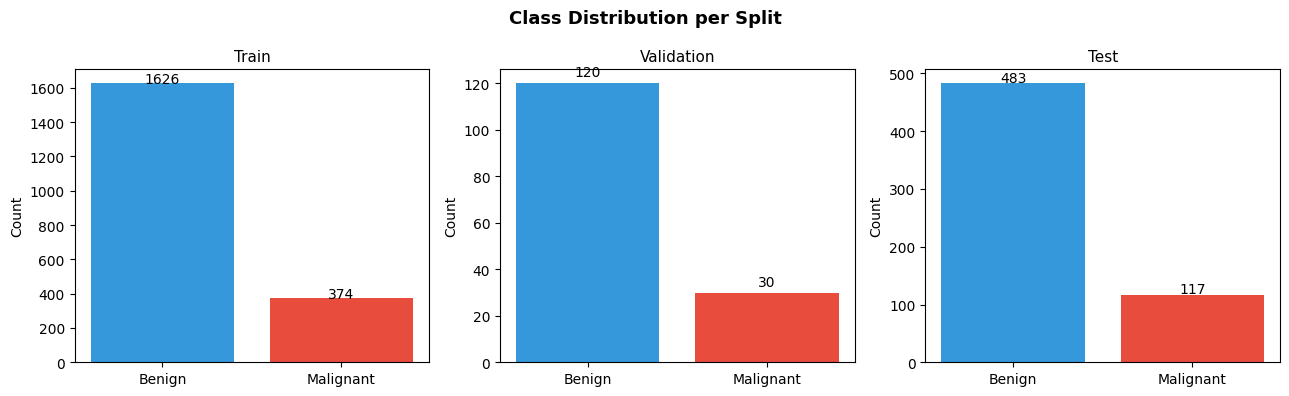

In [ ]:

# EDA 1: Class distribution bar
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#3498db', '#e74c3c']
for ax, (df, title) in zip(axes, [
    (train_gt, 'Train'), (val_gt, 'Validation'), (test_gt, 'Test')
]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(['Benign', 'Malignant'], counts.values, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 3, str(v), ha='center', fontsize=10)
plt.suptitle('Class Distribution per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

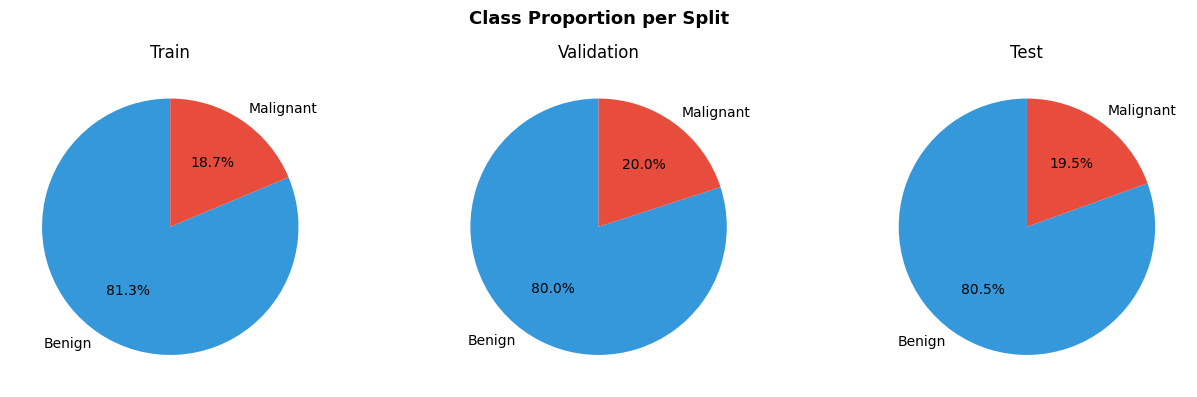

In [ ]:
# EDA 2: Pie chart
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (df, title) in zip(axes, [
    (train_gt, 'Train'), (val_gt, 'Validation'), (test_gt, 'Test')
]):
    counts = df['label'].value_counts().sort_index()
    ax.pie(counts.values, labels=['Benign', 'Malignant'],
           colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(title)
plt.suptitle('Class Proportion per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

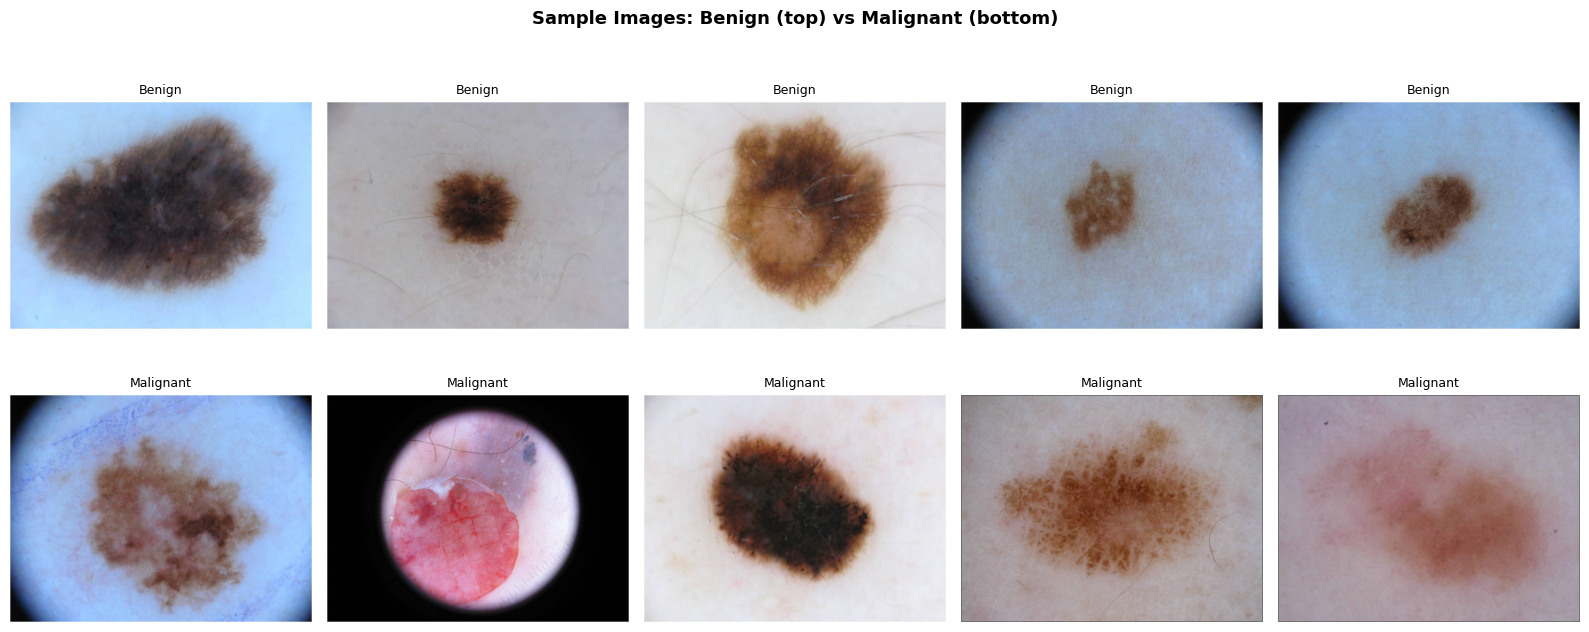

In [ ]:
# EDA 3: Sample images benign vs malignant
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for row_idx, (label_val, label_name) in enumerate([(0, 'Benign'), (1, 'Malignant')]):
    samples = train_gt[train_gt['label'] == label_val]['image_id'].iloc[:5]
    for col_idx, img_id in enumerate(samples):
        img_path = Path(TRAIN_IMG) / f'{img_id}.jpg'
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].set_title(f'{label_name}', fontsize=9)
        axes[row_idx, col_idx].axis('off')
plt.suptitle('Sample Images: Benign (top) vs Malignant (bottom)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# EDA 4: Average RGB per class
print('\nComputing average RGB per class...')
rgb_stats = {'Benign': [], 'Malignant': []}
for _, row in train_gt.iterrows():
    img_path = Path(TRAIN_IMG) / f'{row["image_id"]}.jpg'
    img = cv2.imread(str(img_path))
    if img is None: continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    label_name = 'Malignant' if row['label'] == 1 else 'Benign'
    rgb_stats[label_name].append(img_rgb.mean(axis=(0,1)))

for label_name, vals in rgb_stats.items():
    arr = np.array(vals)
    print(f'  {label_name}: R={arr[:,0].mean():.1f}, '
          f'G={arr[:,1].mean():.1f}, B={arr[:,2].mean():.1f}')

print('\nEDA done ✓')


Computing average RGB per class...
  Benign: R=181.4, G=152.4, B=141.1
  Malignant: R=176.6, G=144.0, B=132.5

EDA done ✓


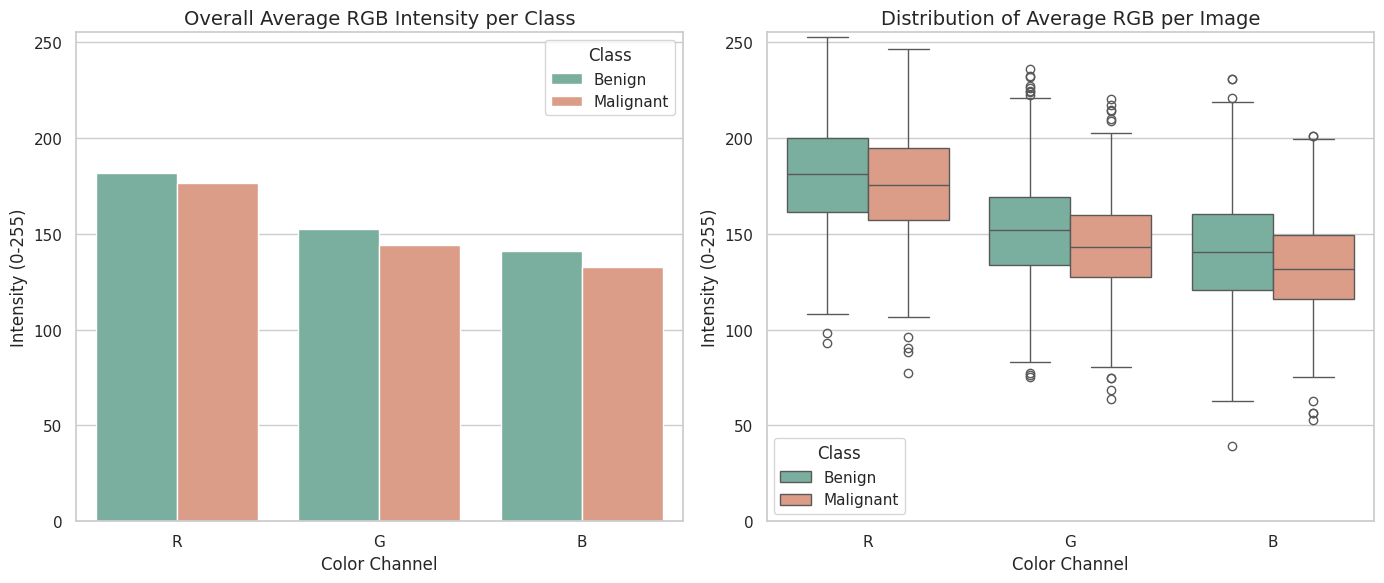


Visualisasi EDA selesai ✓


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -- Kode Anda sebelumnya (pengumpulan rgb_stats) ada di sini --

# 1. Menyiapkan data ke dalam bentuk DataFrame agar mudah diplot dengan Seaborn
plot_data = []
for label_name, vals in rgb_stats.items():
    arr = np.array(vals) # arr shape: (jumlah_gambar, 3)
    for i in range(arr.shape[0]):
        plot_data.append({
            'Class': label_name,
            'R': arr[i, 0],
            'G': arr[i, 1],
            'B': arr[i, 2]
        })

df_rgb = pd.DataFrame(plot_data)

# Melakukan 'melt' DataFrame agar formatnya panjang (long-format), cocok untuk seaborn hue
df_melted = df_rgb.melt(id_vars='Class', var_name='Channel', value_name='Average Intensity')

# 2. Membuat visualisasi (Bar Plot dan Box Plot)
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Warna kustom (Red, Green, Blue) yang disesuaikan dengan intensitas kelas
# Gunakan warna yang sedikit berbeda untuk Benign dan Malignant agar kontras
palettes = {'Benign': '#72B6A1', 'Malignant': '#E9967A'} 

# --- Plot 1: Barplot (Rata-rata RGB keseluruhan per kelas) ---
plt.subplot(1, 2, 1)
sns.barplot(
    data=df_melted, 
    x='Channel', 
    y='Average Intensity', 
    hue='Class',
    palette=palettes,
    errorbar=None # Matikkan error bar agar fokus ke mean absolut seperti hasil print
)
plt.title('Overall Average RGB Intensity per Class', fontsize=14)
plt.ylabel('Intensity (0-255)')
plt.xlabel('Color Channel')
plt.ylim(0, 255)

# --- Plot 2: Boxplot (Distribusi rata-rata RGB per gambar) ---
plt.subplot(1, 2, 2)
sns.boxplot(
    data=df_melted, 
    x='Channel', 
    y='Average Intensity', 
    hue='Class',
    palette=palettes
)
plt.title('Distribution of Average RGB per Image', fontsize=14)
plt.ylabel('Intensity (0-255)')
plt.xlabel('Color Channel')
plt.ylim(0, 255)

plt.tight_layout()
plt.show()

print('\nVisualisasi EDA selesai ✓')

## 4. Preprocessing Functions
Hair removal (DullRazor-lite) + CLAHE

In [ ]:
TARGET_SIZE = (256, 256)

def remove_hair(img_bgr):
    """
    DullRazor-lite: blackhat morphology → threshold → inpaint.
    Works on BGR image. Returns BGR image.
    """
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    # Threshold hair pixels
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    # Inpaint
    cleaned = cv2.inpaint(img_bgr, hair_mask, inpaintRadius=3,
                          flags=cv2.INPAINT_TELEA)
    return cleaned

def apply_clahe(img_bgr):
    """CLAHE on L channel of LAB color space."""
    lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq  = clahe.apply(l)
    enhanced = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

def preprocess(img_bgr, size=TARGET_SIZE):
    """Full preprocessing pipeline for one image."""
    img = remove_hair(img_bgr)
    img = apply_clahe(img)
    img = cv2.resize(img, size)
    return img

print('Preprocessing functions defined ✓')

Preprocessing functions defined ✓


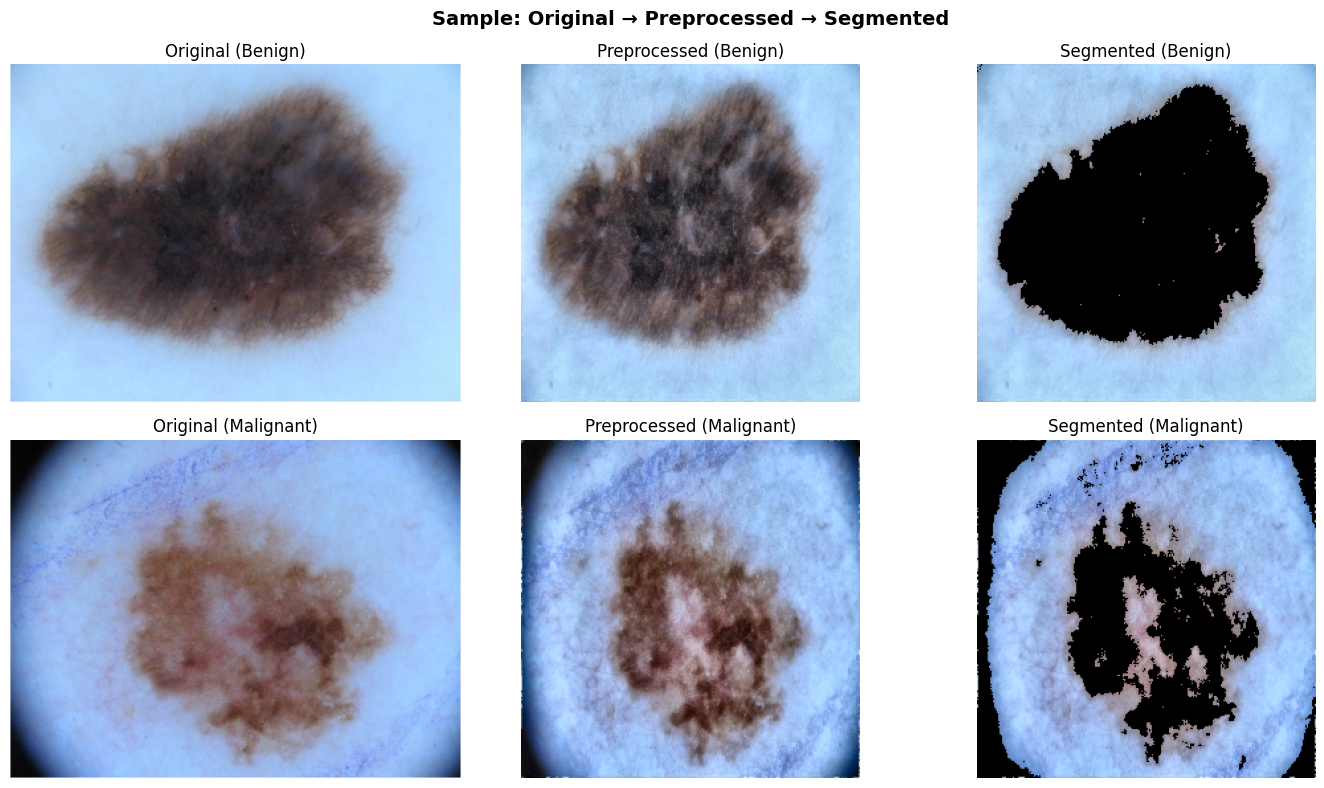

In [ ]:
# ── Sample Visualization ──────────────────────────────────────────────────────
# Ambil 1 sample benign dan 1 malignant
sample_benign    = train_gt[train_gt['label'] == 0]['image_id'].iloc[0]
sample_malignant = train_gt[train_gt['label'] == 1]['image_id'].iloc[0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row_idx, (img_id, label_name) in enumerate([
    (sample_benign,    'Benign'),
    (sample_malignant, 'Malignant')
]):
    img_path = Path(TRAIN_IMG) / f'{img_id}.jpg'
    img_bgr  = cv2.imread(str(img_path))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Preprocessed
    img_pre     = preprocess(img_bgr)
    img_pre_rgb = cv2.cvtColor(img_pre, cv2.COLOR_BGR2RGB)
    
    # Otsu segmentation mask
    gray = cv2.cvtColor(img_pre, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    segmented = img_pre.copy()
    segmented[mask == 0] = [0, 0, 0]
    segmented_rgb = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)
    
    # Plot
    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f'Original ({label_name})')
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(img_pre_rgb)
    axes[row_idx, 1].set_title(f'Preprocessed ({label_name})')
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(segmented_rgb)
    axes[row_idx, 2].set_title(f'Segmented ({label_name})')
    axes[row_idx, 2].axis('off')

plt.suptitle('Sample: Original → Preprocessed → Segmented', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Extraction Functions
LBP + GLCM (Haralick) + HOG + LAB Histogram → 768-dim vector

In [ ]:
# ── LBP ───────────────────────────────────────────────────────────────────────
def extract_lbp(gray, P=24, R=3, n_bins=64):
    lbp = local_binary_pattern(gray, P=P, R=R, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins,
                            range=(0, P+2), density=True)
    return hist  # (64,)

# ── GLCM / Haralick ───────────────────────────────────────────────────────────
def extract_glcm(gray):
    # Use mahotas for faster Haralick (13 features × 4 directions → mean)
    feats = mahotas.features.haralick(gray).mean(axis=0)  # (13,)
    return feats

# ── HOG ───────────────────────────────────────────────────────────────────────
def extract_hog(gray, orientations=8, pixels_per_cell=(16,16),
                cells_per_block=(2,2)):
    feat = hog(gray,
               orientations=orientations,
               pixels_per_cell=pixels_per_cell,
               cells_per_block=cells_per_block,
               block_norm='L2-Hys',
               feature_vector=True)
    return feat  # variable length but fixed for fixed input size

# ── LAB Color Histogram ────────────────────────────────────────────────────────
def extract_lab_hist(img_bgr, bins=32):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    feats = []
    for ch, (lo, hi) in enumerate([(0,100),(-128,127),(-128,127)]):
        h, _ = np.histogram(lab[:,:,ch].ravel(), bins=bins,
                             range=(lo, hi), density=True)
        feats.append(h)
    return np.concatenate(feats)  # (96,)

def extract_hsv_hist(img_bgr, bins=32):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    feats = []
    for ch, (lo, hi) in enumerate([(0,180),(0,255),(0,255)]):
        h, _ = np.histogram(hsv[:,:,ch].ravel(), bins=bins,
                             range=(lo, hi), density=True)
        feats.append(h)
    return np.concatenate(feats)  # (96,)

# ── ORB + Bag of Visual Words ─────────────────────────────────────────────────
from sklearn.cluster import MiniBatchKMeans

N_CLUSTERS = 50  # vocabulary size

def build_bovw_vocabulary(img_folder, gt_df, n_clusters=N_CLUSTERS, max_imgs=500):
    orb = cv2.ORB_create(nfeatures=500)
    all_descriptors = []
    
    for img_id in tqdm(gt_df['image_id'].iloc[:max_imgs], desc='Building BoVW vocab'):
        img_path = Path(img_folder) / f'{img_id}.jpg'
        if not img_path.exists():
            continue
        img = cv2.imread(str(img_path))
        if img is None: continue
        img = preprocess(img)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, des = orb.detectAndCompute(gray, None)
        if des is not None:
            all_descriptors.append(des)
    
    all_descriptors = np.vstack(all_descriptors)
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(all_descriptors)
    return kmeans

def extract_bovw(img_bgr, kmeans, n_clusters=N_CLUSTERS):
    orb = cv2.ORB_create(nfeatures=500)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, des = orb.detectAndCompute(gray, None)
    hist = np.zeros(n_clusters)
    if des is not None:
        labels = kmeans.predict(des)
        for l in labels:
            hist[l] += 1
        hist = hist / (hist.sum() + 1e-7)
    return hist  # (50,)

# ── Combined extractor ────────────────────────────────────────────────────────
# Build vocabulary dulu (jalankan sekali sebelum Cell 6)
bovw_kmeans = build_bovw_vocabulary(TRAIN_IMG, train_gt)

def extract_features(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    lbp_feat  = extract_lbp(gray)
    glcm_feat = extract_glcm(gray)
    hog_feat  = extract_hog(gray)
    lab_feat  = extract_lab_hist(img_bgr)
    hsv_feat  = extract_hsv_hist(img_bgr)
    bovw_feat = extract_bovw(img_bgr, bovw_kmeans)  # ← tambahan
    return np.concatenate([lbp_feat, glcm_feat, hog_feat, lab_feat, hsv_feat, bovw_feat])

# Test on dummy image
dummy = np.random.randint(0, 255, (256,256,3), dtype=np.uint8)
print(f'Feature vector length: {extract_features(dummy).shape[0]}')

Building BoVW vocab: 100%|██████████| 500/500 [02:43<00:00,  3.06it/s]


Feature vector length: 7519


## 6. Build Feature Matrix
Loop through Train / Val / Test images

In [ ]:
#dijalankan klw .npz sudah ada (untuk nge hapus cache)
import os
for f in ['features_Train.npz', 'features_Val.npz', 'features_Test.npz']:
    path = f'/kaggle/working/{f}'
    if os.path.exists(path): 
        os.remove(path)
        print(f'Deleted: {path}')

In [ ]:
from multiprocessing import Pool

def process_row(args):
    img_path, label = args
    img = cv2.imread(str(img_path))
    if img is None: return None
    img = preprocess(img)
    return extract_features(img), label

def build_feature_matrix(gt_df, img_folder, split_name=''):
    img_folder = Path(img_folder)
    
    cache_path = Path(f'/kaggle/working/features_{split_name}.npz')
    if cache_path.exists():
        data = np.load(cache_path)
        return data['X'], data['y'], list(data['ids'])
    
    features, labels, ids = [], [], []
    
    for _, row in tqdm(gt_df.iterrows(), total=len(gt_df),
                       desc=f'Extracting [{split_name}]'):
        img_id = row['image_id']
        img_path = img_folder / f'{img_id}.jpg'
        if not img_path.exists():
            img_path = img_folder / f'{img_id}.jpeg'
        if not img_path.exists():
            continue
        img = cv2.imread(str(img_path))
        if img is None: continue
        img = preprocess(img)
        features.append(extract_features(img))
        labels.append(row['label'])
        ids.append(img_id)
    
    X = np.array(features, dtype=np.float32)
    y = np.array(labels,   dtype=np.int32)
    np.savez(cache_path, X=X, y=y, ids=np.array(ids))
    print(f'[{split_name}] X={X.shape}  y={y.shape}  '
          f'malignant={y.sum()}  benign={(y==0).sum()}')
    return X, y, ids

In [ ]:
X_train, y_train, ids_train = build_feature_matrix(train_gt, TRAIN_IMG, 'Train')
X_val,   y_val,   ids_val   = build_feature_matrix(val_gt,   VAL_IMG,   'Val')
X_test,  y_test,  ids_test  = build_feature_matrix(test_gt,  TEST_IMG,  'Test')

Extracting [Train]: 100%|██████████| 2000/2000 [35:02<00:00,  1.05s/it] 


[Train] X=(2000, 7519)  y=(2000,)  malignant=374  benign=1626


Extracting [Val]: 100%|██████████| 150/150 [05:26<00:00,  2.18s/it]


[Val] X=(150, 7519)  y=(150,)  malignant=30  benign=120


Extracting [Test]: 100%|██████████| 600/600 [36:18<00:00,  3.63s/it]  

[Test] X=(600, 7519)  y=(600,)  malignant=117  benign=483


## 7. Handle Class Imbalance
Strategy: **oversample minority (malignant) on training set only**

Val & Test dibiarkan original (supaya evaluasi valid).

In [ ]:
def oversample_minority(X, y, random_state=42):
    """
    Simple random oversampling — upsample minority class to match majority.
    """
    classes, counts = np.unique(y, return_counts=True)
    majority_class  = classes[np.argmax(counts)]
    minority_class  = classes[np.argmin(counts)]
    n_majority      = counts.max()
    
    X_maj = X[y == majority_class]
    X_min = X[y == minority_class]
    y_maj = y[y == majority_class]
    y_min = y[y == minority_class]
    
    X_min_up, y_min_up = resample(
        X_min, y_min,
        replace=True,
        n_samples=n_majority,
        random_state=random_state
    )
    
    X_bal = np.vstack([X_maj, X_min_up])
    y_bal = np.concatenate([y_maj, y_min_up])
    
    # Shuffle
    idx = np.random.RandomState(random_state).permutation(len(y_bal))
    return X_bal[idx], y_bal[idx]

X_train_bal, y_train_bal = oversample_minority(X_train, y_train)
print(f'Before oversampling : {np.unique(y_train, return_counts=True)}')
print(f'After  oversampling : {np.unique(y_train_bal, return_counts=True)}')

Before oversampling : (array([0, 1], dtype=int32), array([1626,  374]))
After  oversampling : (array([0, 1], dtype=int32), array([1626, 1626]))


## 8. Feature Scaling

In [ ]:
# Replace NaN dan Inf dengan 0
X_train_bal = np.nan_to_num(X_train_bal, nan=0.0, posinf=0.0, neginf=0.0)
X_val       = np.nan_to_num(X_val,       nan=0.0, posinf=0.0, neginf=0.0)
X_test      = np.nan_to_num(X_test,      nan=0.0, posinf=0.0, neginf=0.0)

In [ ]:
scaler = StandardScaler()

# Fit ONLY on training data
X_train_sc = scaler.fit_transform(X_train_bal)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Scaling done ✓')
print(f'Train: {X_train_sc.shape}  |  Val: {X_val_sc.shape}  |  Test: {X_test_sc.shape}')

Scaling done ✓
Train: (3252, 7519)  |  Val: (150, 7519)  |  Test: (600, 7519)


## 9. Train HGBDT (Best Model)
Hyperparameters dari Pattnaik et al. + tuning untuk binary task

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgbdt = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

print('Training HistGBDT...')
hgbdt.fit(X_train_sc, y_train_bal)
print('Training done ✓')

Training HistGBDT...
Training done ✓


## 10. Compare with Random Forest (baseline)

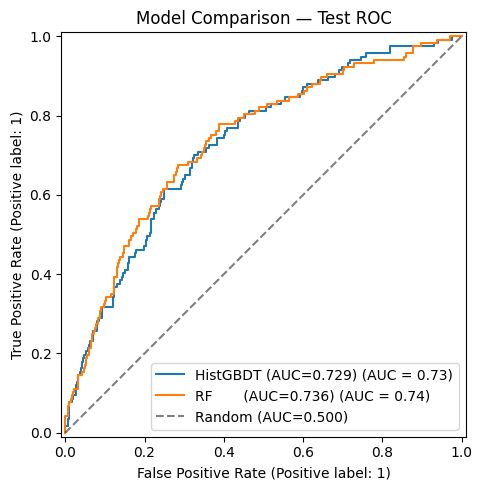


HistGBDT Test AUC : 0.7289
RF       Test AUC : 0.7359

→ Best model : RF


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',   # RF bisa pakai class_weight sbg alternatif
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train_bal)
y_prob_hgbdt = hgbdt.predict_proba(X_test_sc)[:, 1]
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1] # Tambahkan baris ini
auc_rf    = roc_auc_score(y_test, y_prob_rf)
auc_hgbdt = roc_auc_score(y_test, y_prob_hgbdt)

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_hgbdt, name=f'HistGBDT (AUC={auc_hgbdt:.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf,    name=f'RF       (AUC={auc_rf:.3f})',    ax=ax)
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.500)')
ax.set_title('Model Comparison — Test ROC')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nHistGBDT Test AUC : {auc_hgbdt:.4f}')
print(f'RF       Test AUC : {auc_rf:.4f}')
winner = 'HistGBDT' if auc_hgbdt >= auc_rf else 'RF'
print(f'\n→ Best model : {winner}')

## 11. Evaluate on Validation Set


  Validation Evaluation  (threshold=0.5)
               precision    recall  f1-score   support

   Benign (0)       0.80      0.99      0.89       120
Malignant (1)       0.50      0.03      0.06        30

     accuracy                           0.80       150
    macro avg       0.65      0.51      0.48       150
 weighted avg       0.74      0.80      0.72       150

ROC-AUC: 0.6692
MCC    : 0.0872


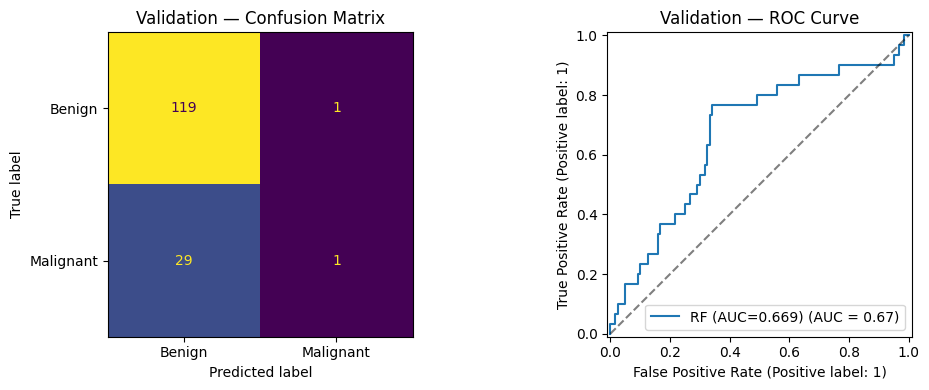

In [ ]:
from sklearn.metrics import matthews_corrcoef

def evaluate(model, X, y_true, split_name='', threshold=0.5):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    print(f'\n{'='*50}')
    print(f'  {split_name} Evaluation  (threshold={threshold})')
    print(f'{'='*50}')
    print(classification_report(y_true, y_pred,
                                  target_names=['Benign (0)', 'Malignant (1)']))
    auc = roc_auc_score(y_true, y_prob)

    mcc = matthews_corrcoef(y_true, y_pred)
    print(f'ROC-AUC: {auc:.4f}')
    print(f'MCC    : {mcc:.4f}')

    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Benign','Malignant']).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'{split_name} — Confusion Matrix')
    
    # ROC curve
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1],
                                      name=f'RF (AUC={auc:.3f})')
    axes[1].plot([0,1],[0,1],'k--', alpha=0.5)
    axes[1].set_title(f'{split_name} — ROC Curve')
    
    plt.tight_layout()
    plt.show()
    return auc

val_auc = evaluate(rf, X_val_sc, y_val, split_name='Validation')

In [ ]:
print(f'RF n_features: {rf.n_features_in_}')
print(f'X_train_sc shape: {X_train_sc.shape}')

RF n_features: 7519
X_train_sc shape: (3252, 7519)


## 12. Final Evaluation on Test Set

Best threshold : 0.30
Best F1 malignant : 0.4688

  Test (optimal threshold) Evaluation  (threshold=0.29999999999999993)
               precision    recall  f1-score   support

   Benign (0)       0.90      0.71      0.79       483
Malignant (1)       0.36      0.68      0.47       117

     accuracy                           0.70       600
    macro avg       0.63      0.69      0.63       600
 weighted avg       0.79      0.70      0.73       600

ROC-AUC: 0.7359
MCC    : 0.3151


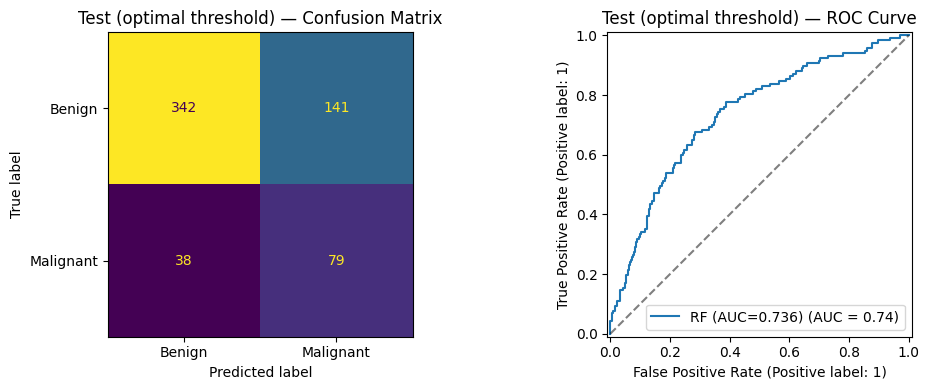


  Test (high sensitivity) Evaluation  (threshold=0.15)
               precision    recall  f1-score   support

   Benign (0)       0.92      0.16      0.28       483
Malignant (1)       0.21      0.94      0.35       117

     accuracy                           0.32       600
    macro avg       0.57      0.55      0.31       600
 weighted avg       0.78      0.32      0.29       600

ROC-AUC: 0.7359
MCC    : 0.1173


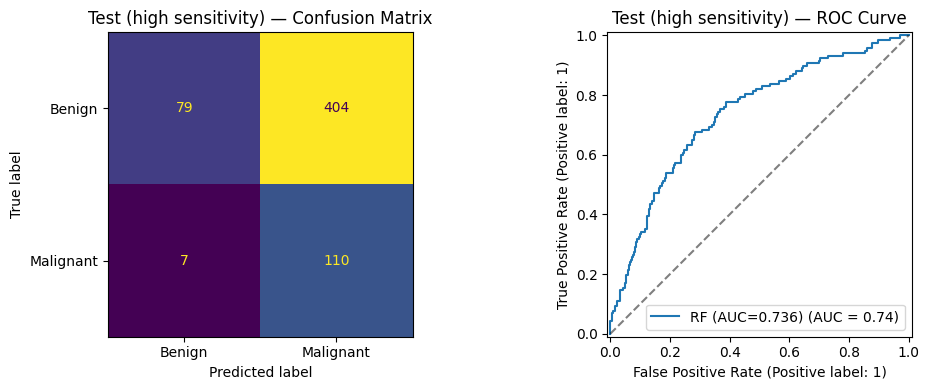

np.float64(0.7359275185362143)

In [ ]:
from sklearn.metrics import f1_score

y_prob_test = rf.predict_proba(X_test_sc)[:, 1]

best_thresh, best_f1 = 0.5, 0
for thresh in np.arange(0.1, 0.6, 0.01):
    y_pred_t = (y_prob_test >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_t, pos_label=1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f'Best threshold : {best_thresh:.2f}')
print(f'Best F1 malignant : {best_f1:.4f}')

# Balanced
test_auc = evaluate(rf, X_test_sc, y_test, split_name='Test (optimal threshold)', threshold=best_thresh)

# High sensitivity
evaluate(rf, X_test_sc, y_test, split_name='Test (high sensitivity)', threshold=0.15)

## 13. Feature Importance (RF)

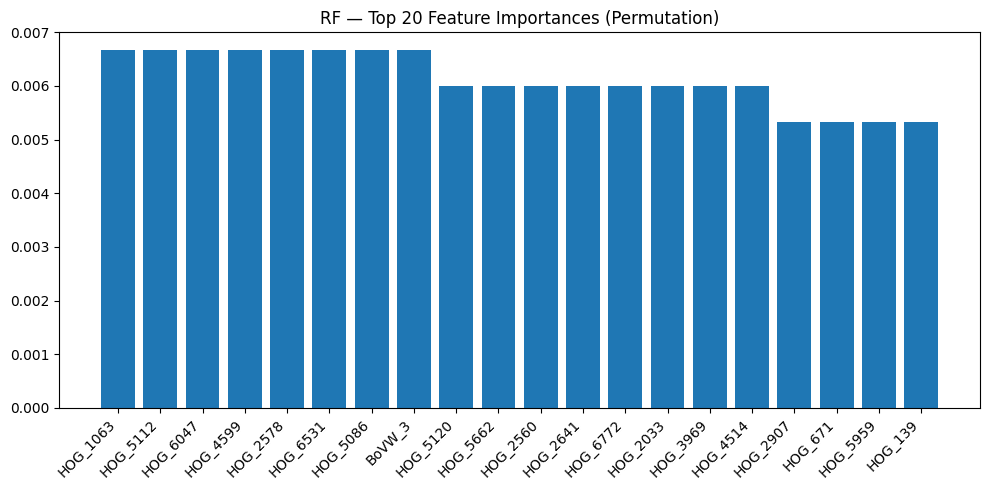

In [ ]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rf, X_val_sc, y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
importances = result.importances_mean
n_feat = len(importances)

lbp_names  = [f'LBP_{i}'    for i in range(64)]
glcm_names = [f'GLCM_{i}'   for i in range(13)]
hog_n      = n_feat - 64 - 13 - 96 - 96 - 50
hog_names  = [f'HOG_{i}'    for i in range(hog_n)]
lab_names  = [f'LAB_{i}'    for i in range(96)]
hsv_names  = [f'HSV_{i}'    for i in range(96)]
bovw_names = [f'BoVW_{i}'   for i in range(50)]
feat_names = lbp_names + glcm_names + hog_names + lab_names + hsv_names + bovw_names

top_k   = 20
top_idx = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(10, 5))
plt.bar(range(top_k), importances[top_idx])
plt.xticks(range(top_k), [feat_names[i] for i in top_idx], rotation=45, ha='right')
plt.title(f'RF — Top {top_k} Feature Importances (Permutation)')
plt.tight_layout()
plt.show()

## 14. Save Model

In [ ]:
joblib.dump(rf,   '/kaggle/working/rf_skinical.pkl')
joblib.dump(scaler, '/kaggle/working/scaler_skinical.pkl')

joblib.dump(hgbdt,   '/kaggle/working/hgbdt_skinical.pkl')
joblib.dump(scaler, '/kaggle/working/scaler_hgbdt_skinical.pkl')
print('Model + scaler saved to /kaggle/working/ ✓')

Model + scaler saved to /kaggle/working/ ✓


In [ ]:
joblib.dump(bovw_kmeans, '/kaggle/working/bovw_kmeans.pkl')

['/kaggle/working/bovw_kmeans.pkl']

## 15. Quick Inference Demo
Simulate predicting a single new image

In [ ]:
def predict_single(img_path, model, scaler, threshold=0.5):
    img  = cv2.imread(str(img_path))
    if img is None:
        raise FileNotFoundError(f'Cannot read: {img_path}')
    img   = preprocess(img)
    feat  = extract_features(img).reshape(1, -1)
    feat_sc = scaler.transform(feat)
    prob  = model.predict_proba(feat_sc)[0, 1]
    label = 'Malignant' if prob >= threshold else 'Benign'
    return label, prob

# Example: pick the first test image
sample_id   = ids_test[0]
sample_path = Path(TEST_IMG) / f'{sample_id}.jpg'
label, prob = predict_single(sample_path, rf, scaler)
print(f'Image  : {sample_id}')
print(f'True   : {"Malignant" if y_test[0]==1 else "Benign"}')
print(f'Predict: {label}  (prob_malignant={prob:.4f})')

Image  : ISIC_0012086
True   : Benign
Predict: Benign  (prob_malignant=0.4112)
